## Polynomial Regression

In [42]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import pickle

In [43]:
# ...existing code...
# Load training data (this repo uses 2.3.1.training_data.csv)
training_data = pd.read_csv("2.3.1.training_data.csv")

# ---- quick-edit config ----
FEATURE_COLS = ["k/d", "matchs_played"]  # change as needed
TARGET_COL = "win%"  # change as needed
# ---------------------------

# Validate column names
missing_x = [c for c in FEATURE_COLS if c not in training_data.columns]
if missing_x:
    raise ValueError(f"Missing feature columns: {missing_x}")
if TARGET_COL not in training_data.columns:
    raise ValueError(f"Missing target column: {TARGET_COL}")

# Keep only needed columns and drop missing rows
model_df = training_data[FEATURE_COLS + [TARGET_COL]].dropna()

# Convert to numpy for sklearn
x = model_df[FEATURE_COLS].to_numpy(dtype=float)  # shape: (n_samples, n_features)
y = model_df[TARGET_COL].to_numpy(dtype=float)  # shape: (n_samples,)

print("X shape:", x.shape, "| features:", FEATURE_COLS)
print("y shape:", y.shape, "| target:", TARGET_COL)
# ...existing code...

X shape: (286, 2) | features: ['k/d', 'matchs_played']
y shape: (286,) | target: win%


In [ ]:
# Instantiate as one pipeline (transform + regressor)
DEGREE = 4  # quick-edit
model_A = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=DEGREE, include_bias=False)),
        ("reg", LinearRegression()),
    ]
)

print("Instantiated polynomial pipeline.")

Instantiated polynomial pipeline.


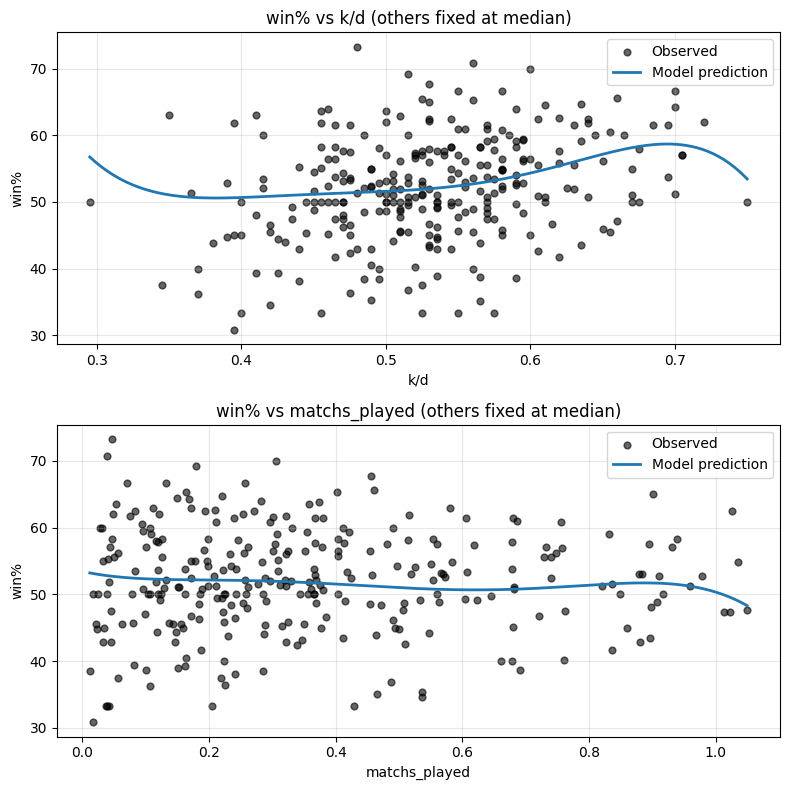

In [45]:
# ...existing code...
# Fit polynomial pipeline
model_A.fit(x, y)

# Predict on training data
y_pred = model_A.predict(x)

# One panel per feature (works for 1 or many features)
n_features = x.shape[1]
fig, axes = plt.subplots(
    nrows=n_features, ncols=1, figsize=(8, 4 * n_features), squeeze=False
)

x_ref = np.median(x, axis=0)  # hold other features constant at median

for i in range(n_features):
    ax = axes[i, 0]

    # observed points
    ax.scatter(x[:, i], y, s=24, alpha=0.6, color="black", label="Observed")

    # model curve for this feature (others fixed)
    x_i = x[:, i]
    x_grid = np.linspace(x_i.min(), x_i.max(), 250)

    x_plot = np.tile(x_ref, (len(x_grid), 1))
    x_plot[:, i] = x_grid

    # Pipeline handles polynomial transform internally
    y_grid_pred = model_A.predict(x_plot)
    ax.plot(
        x_grid, y_grid_pred, color="tab:blue", linewidth=2, label="Model prediction"
    )

    ax.set_title(f"{TARGET_COL} vs {FEATURE_COLS[i]} (others fixed at median)")
    ax.set_xlabel(FEATURE_COLS[i])
    ax.set_ylabel(TARGET_COL)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()
# ...existing code...

In [46]:
# ...existing code...
filename = "polynomial_model.sav"
with open("../2.4.Model_Testing_and_Evaluation/" + filename, "wb") as f:
    pickle.dump(model_A, f)
# ...existing code...